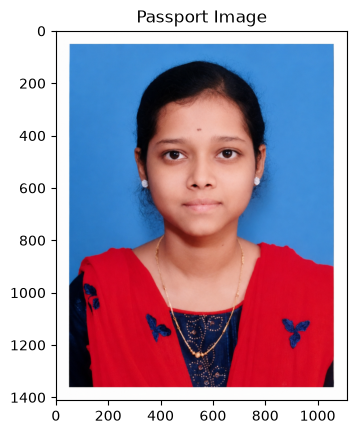

In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
faceImage = cv2.imread('Passport.png')  
plt.imshow(faceImage[:,:,::-1])
plt.title("Passport Image")
plt.show()

In [2]:
faceImage.shape

(1412, 1114, 3)

Text(0.5, 1.0, 'Sunglass Image')

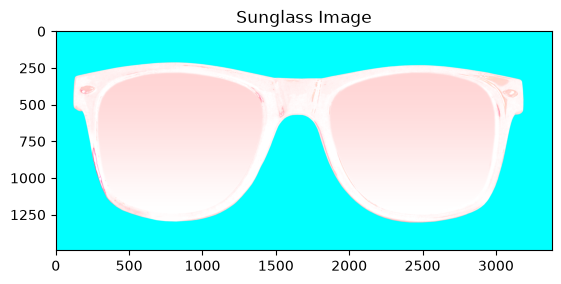

In [3]:
glassPNG = cv2.imread('sunglass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);
plt.title("Sunglass Image")

In [4]:
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


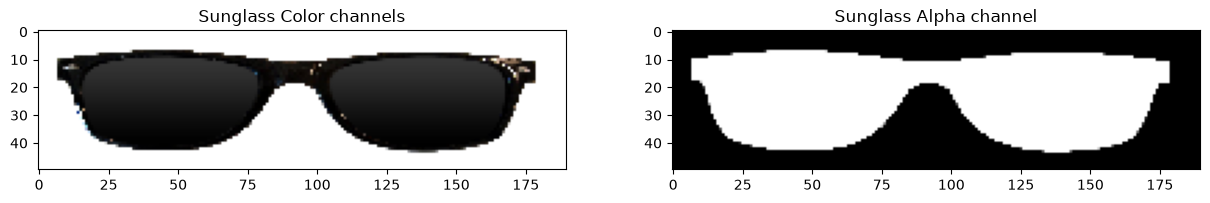

In [5]:
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]
plt.figure(figsize=[15,15])
plt.subplot(121);
plt.imshow(glassBGR[:,:,::-1]);
plt.title('Sunglass Color channels');
plt.subplot(122);
plt.imshow(glassMask1,cmap='gray');
plt.title('Sunglass Alpha channel');

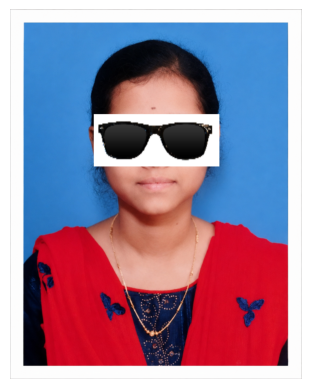

In [6]:

faceWithGlassesNaive = faceImage.copy()
x, y = 320, 400
target_w = 480
target_h = 200
glassResized = cv2.resize(glassBGR, (target_w, target_h))
faceWithGlassesNaive[y:y+target_h, x:x+target_w] = glassResized
plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.axis("off")
plt.show()

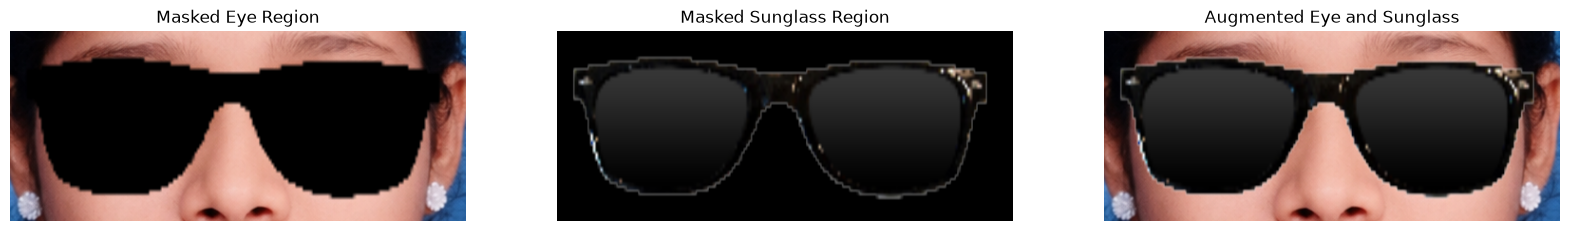

In [7]:

glassAlpha = glassPNG[..., 3] / 255.0
glassBGR = glassPNG[..., :3]


glassBGR = cv2.resize(glassBGR, (target_w, target_h))
glassAlpha = cv2.resize(glassAlpha, (target_w, target_h))


eyeRoi = faceImage[y:y+target_h, x:x+target_w].copy()


maskedEye = eyeRoi * (1 - glassAlpha[..., np.newaxis])
maskedGlass = glassBGR * glassAlpha[..., np.newaxis]
eyeRoiFinal = maskedEye + maskedGlass


maskedEye_disp = np.clip(maskedEye.astype(np.uint8), 0, 255)
maskedGlass_disp = np.clip(maskedGlass.astype(np.uint8), 0, 255)
eyeRoiFinal_disp = np.clip(eyeRoiFinal.astype(np.uint8), 0, 255)


plt.figure(figsize=[20,20])
plt.subplot(131)
plt.imshow(maskedEye_disp[..., ::-1])
plt.title("Masked Eye Region")
plt.axis("off")

plt.subplot(132)
plt.imshow(maskedGlass_disp[..., ::-1])
plt.title("Masked Sunglass Region")
plt.axis("off")

plt.subplot(133)
plt.imshow(eyeRoiFinal_disp[..., ::-1])
plt.title("Augmented Eye and Sunglass")
plt.axis("off")
plt.show()

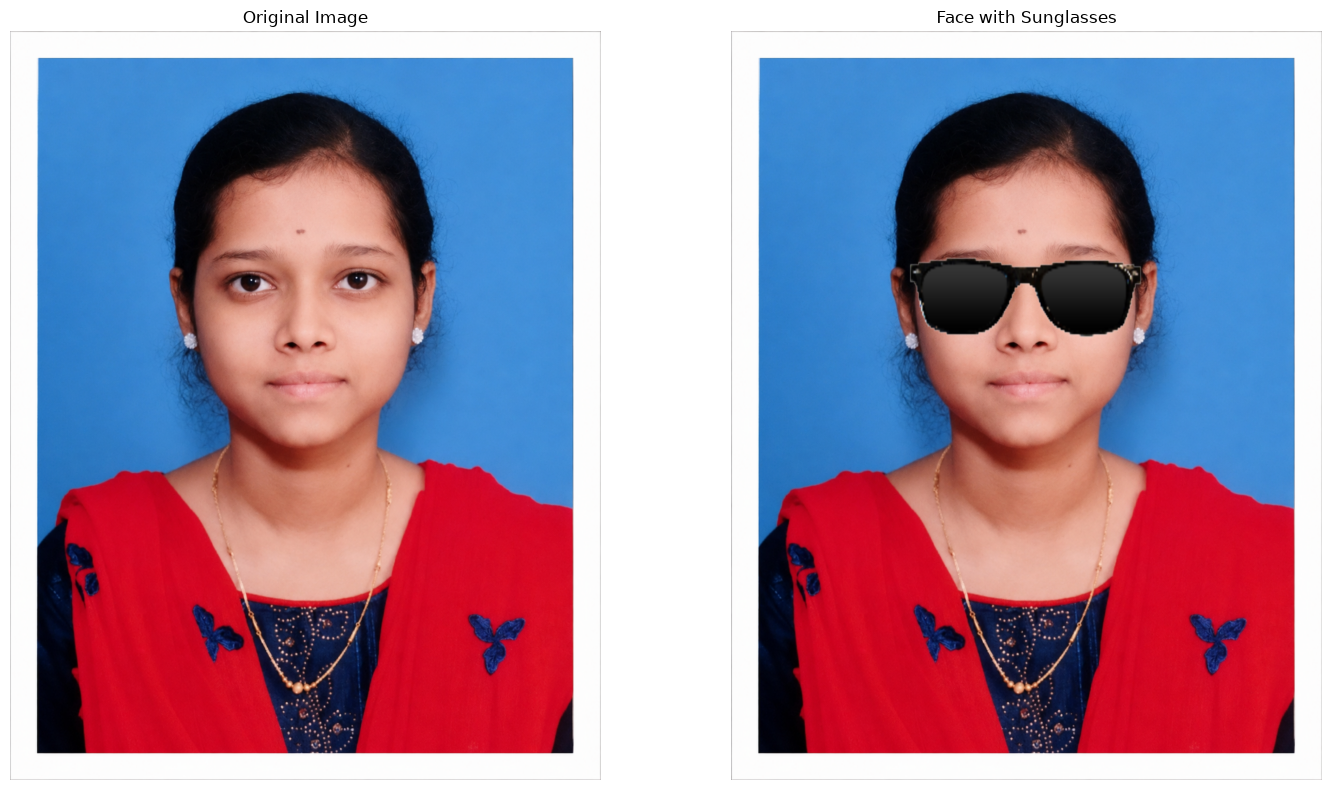

In [9]:

faceWithGlasses = faceImage.copy()


x, y = 320, 400
target_w, target_h = 480, 200
glassBGR = cv2.resize(glassBGR, (target_w, target_h))
glassAlpha = cv2.resize(glassPNG[..., 3]/255.0, (target_w, target_h))

roi = faceWithGlasses[y:y+target_h, x:x+target_w]
for c in range(3):
    roi[..., c] = roi[..., c]*(1-glassAlpha) + glassBGR[..., c]*glassAlpha
faceWithGlasses[y:y+target_h, x:x+target_w] = roi
plt.figure(figsize=[15,8])
plt.subplot(1, 2, 1)
plt.imshow(faceImage[..., ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(faceWithGlasses[..., ::-1])
plt.title("Face with Sunglasses")
plt.axis("off")

plt.tight_layout()
plt.show()